In [6]:
import os
import sys
import numpy as np
import datetime
import importlib
import netCDF4
import xarray as xr
import HydroAI.Plot as hPlot
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

base_FP = '/home/jovyan/01_aurora/'
cpuserver_data_FP = '/home/jovyan/data2/'
sys.path.append(base_FP)

#hydroAI libs
import HydroAI.ERA5_land as hERA5_land
import HydroAI.Grid as hGrid
import HydroAI.Plot as hPlot
import HydroAI.Data as hData
importlib.reload(hERA5_land);
importlib.reload(hPlot);
importlib.reload(hData);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## 1. Import ERA5_land variable

In [2]:
date = datetime.datetime.strptime('2024-01-02', '%Y-%m-%d')
variable_name = 'swvl1'
directory = os.path.join(cpuserver_data_FP, f'ERA5_Land/Global_3_Hourly/')
nc_file = f'{directory}/{date.year}/{date.strftime("%Y.%m.%d")}/ERA5_World_Snow_{date.strftime("%Y%m%d")}.nc'
print(nc_file)

/home/jovyan/data2/ERA5_Land/Global_3_Hourly//2024/2024.01.02/ERA5_World_Snow_20240102.nc


In [3]:
with xr.open_dataset(nc_file) as ds:
    print(ds.data_vars)
    var_data0 = ds[variable_name].values.copy()
    lon = ds['longitude'].values.copy()
    lat = ds['latitude'].values.copy()
    
    try:
        fill_value = np.float64(ds[variable_name]._FillValue)
        var_data[var_data == fill_value] = np.nan
    except AttributeError:
        print("ERA5_land nc file has no FillValue attribute!")
print(ds[variable_name].attrs)

Data variables:
    d2m      (valid_time, latitude, longitude) float32 207MB ...
    t2m      (valid_time, latitude, longitude) float32 207MB ...
    skt      (valid_time, latitude, longitude) float32 207MB ...
    stl1     (valid_time, latitude, longitude) float32 207MB ...
    stl2     (valid_time, latitude, longitude) float32 207MB ...
    stl3     (valid_time, latitude, longitude) float32 207MB ...
    stl4     (valid_time, latitude, longitude) float32 207MB ...
    asn      (valid_time, latitude, longitude) float32 207MB ...
    snowc    (valid_time, latitude, longitude) float32 207MB ...
    rsn      (valid_time, latitude, longitude) float32 207MB ...
    sde      (valid_time, latitude, longitude) float32 207MB ...
    sd       (valid_time, latitude, longitude) float32 207MB ...
    sf       (valid_time, latitude, longitude) float32 207MB ...
    smlt     (valid_time, latitude, longitude) float32 207MB ...
    tsn      (valid_time, latitude, longitude) float32 207MB ...
    src  

In [4]:
print(var_data0.shape)
print(lon)
print(lat)

(8, 1801, 3600)
[0.000e+00 1.000e-01 2.000e-01 ... 3.597e+02 3.598e+02 3.599e+02]
[ 90.   89.9  89.8 ... -89.8 -89.9 -90. ]


# 2. Resampling to 0.25˚ grid

In [5]:
# Conversion from (0, 360) to (-180, 180) & lon, lat 2D array; 
# Resampling
lon_target, lat_target = hGrid.generate_lon_lat_eqdgrid(0.25)
lon_origin, lat_origin = hERA5_land.preprocess_lon_lat(lon.copy(), lat.copy())
var_data = hERA5_land.correct_shape(var_data0.copy())
var_data = hData.Resampling_forloop(lon_target, lat_target, lon_origin, lat_origin, var_data, mag_factor=1)

100%|██████████| 8/8 [00:00<00:00,  8.35it/s]


# 3. Examples of `plot_map_w_latitudinal_mean`

(<Figure size 1000x500 with 3 Axes>, <Axes: >)

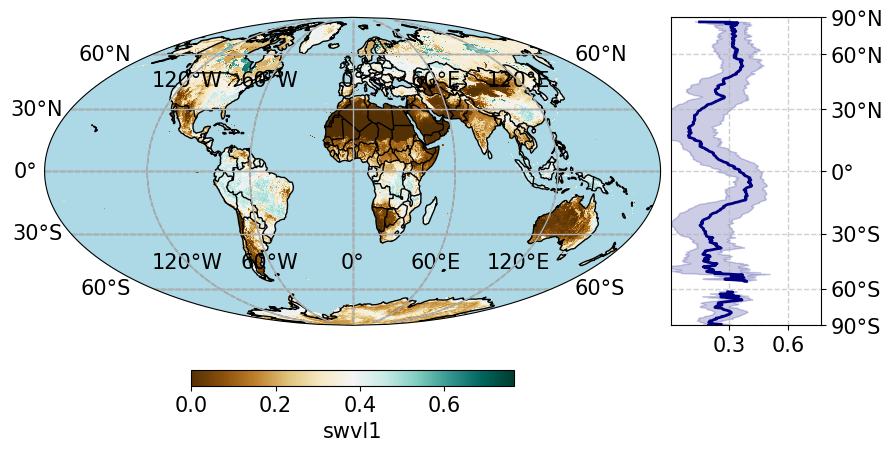

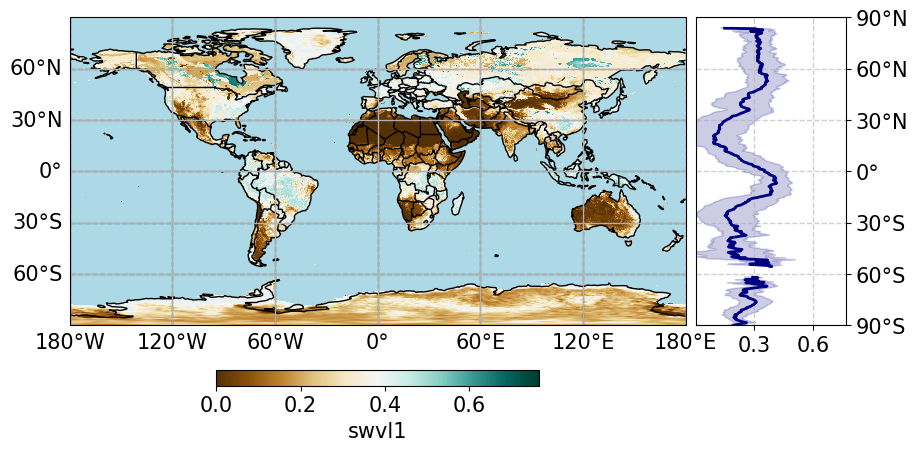

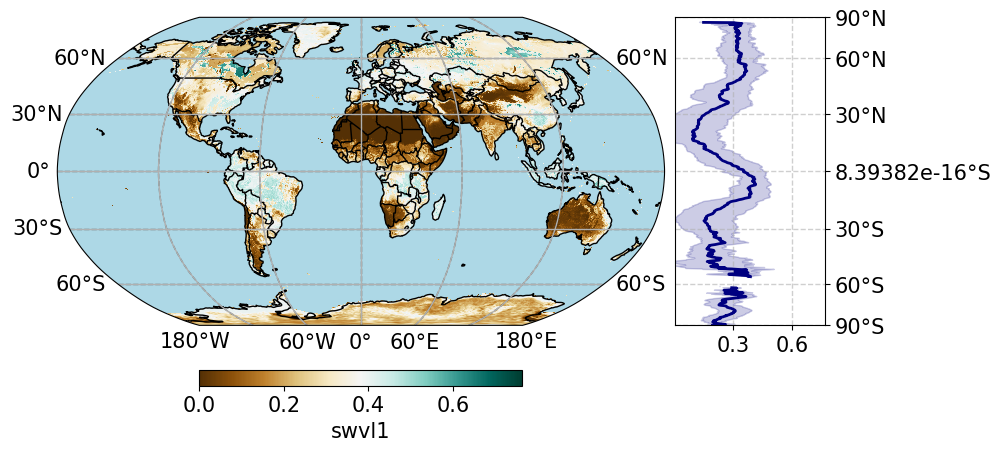

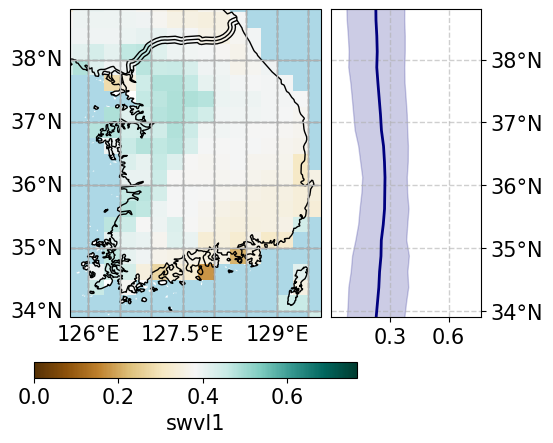

In [7]:
nc_lon, nc_lat = lon_target, lat_target
hPlot.plot_map_w_latitudinal_mean(nc_lon, nc_lat, var_data[:, :, 0], cmap='BrBG', label_title=variable_name, projection='Mollweide')
hPlot.plot_map_w_latitudinal_mean(nc_lon, nc_lat, var_data[:, :, 0], cmap='BrBG', label_title=variable_name, projection='PlateCarree')
hPlot.plot_map_w_latitudinal_mean(nc_lon, nc_lat, var_data[:, :, 0], cmap='BrBG', label_title=variable_name, projection='Robinson')
hPlot.plot_map_w_latitudinal_mean(nc_lon, nc_lat, var_data[:, :, 0], bounds='korea', cmap='BrBG', label_title=variable_name, projection='PlateCarree')

# 4. Examples of `generate_gif`

In [8]:
def plot(nc_lon, nc_lat, values, cmin=None, cmax=None, cmap='jet', label_title='values'):
    projection = 'Mollweide' # PlateCarree, Mollweide
    region = 'global'

    if cmin is None:
        cmin = np.nanmin(values)
    if cmax is None:
        cmax = np.nanmax(values)

    fig, axes = plt.subplots(1, 1, figsize=(7, 4), subplot_kw={'projection': getattr(ccrs, projection)()}, constrained_layout=True)
    hPlot.plot_map(nc_lon, nc_lat, values, cmin, cmax, label_title=label_title, bounds=region, cmap=cmap, projection=projection, ax=axes)
    return fig, axes

nc_lon, nc_lat = lon_target, lat_target
cmin, cmax = np.nanmin(var_data), np.nanmax(var_data)
hPlot.generate_gif(plot, nc_lon, nc_lat, var_data, save_file='./test.gif', cmin=cmin, cmax=cmax, cmap='BrBG')

100%|██████████| 8/8 [00:19<00:00,  2.48s/it]


making gif file...
done! ./test.gif is created.


In [10]:
cmin, cmax = np.nanmin(var_data), np.nanmax(var_data)
hPlot.generate_gif(hPlot.plot_map_w_latitudinal_mean, nc_lon, nc_lat, var_data, save_file='./test.gif', cmin=cmin, cmax=cmax, cmap='BrBG')

100%|██████████| 8/8 [00:19<00:00,  2.39s/it]


making gif file...
done! ./test.gif is created.
